In [1]:
import pandas as pd

# ============================================================
# 1. LOAD STATIC DATA
# ============================================================

df = pd.read_excel(
    "Analysis sheet (FINAL).xlsx",
    sheet_name="Static",
    header=3
)

df.columns = df.columns.astype(str).str.strip()


# ============================================================
# 2. KEEP ONLY DDM VARIABLES
# ============================================================

df = df[[
    "participant",
    "category",
    "Correct_Response",
    "Correct_resp_code",
    "key_response_static.keys",
    "key_response_static.corr",
    "key_response_static.rt"
]].copy()


# ============================================================
# 3. RENAME VARIABLES
# ============================================================

df = df.rename(columns={
    "participant": "subj_idx",
    "category": "group",
    "Correct_Response": "emotion",
    "Correct_resp_code": "correct_code",
    "key_response_static.keys": "response_code",
    "key_response_static.corr": "correct",
    "key_response_static.rt": "rt"
})


# ============================================================
# 4. CLEAN DATA TYPES
# ============================================================

df["rt"] = pd.to_numeric(df["rt"], errors="coerce")

df["correct_code"] = pd.to_numeric(
    df["correct_code"],
    errors="coerce"
)

df["response_code"] = pd.to_numeric(
    df["response_code"],
    errors="coerce"
)

df["correct"] = pd.to_numeric(
    df["correct"],
    errors="coerce"
)


# ============================================================
# 5. REMOVE TRIALS WITH MISSING ESSENTIAL INFORMATION
# ============================================================

df = df.dropna(
    subset=[
        "subj_idx",
        "emotion",
        "rt",
        "correct_code",
        "response_code"
    ]
)


# ============================================================
# 6. KEEP ONLY THE SIX REAL EMOTIONS
# ============================================================

valid_emotions = [
    "Fear",
    "Sadness",
    "Disgust",
    "Anger",
    "Happiness",
    "Surprise"
]

df = df[
    df["emotion"].isin(valid_emotions)
].copy()


# ============================================================
# 7. CREATE BINARY RESPONSE
#
# 1 = CORRECT
# 0 = INCORRECT
# ============================================================

df["response"] = (
    df["correct_code"] == df["response_code"]
).astype(int)


# ============================================================
# 8. REMOVE IMPOSSIBLE RTs
# ============================================================

df = df[df["rt"] > 0.1].copy()


# ============================================================
# 9. CHECK WHETHER OUR RESPONSE CODING MATCHES
#    THE ORIGINAL .corr COLUMN
# ============================================================

agreement = (
    df["response"] == df["correct"]
).mean()

print("\nAgreement between calculated accuracy and original corr:")
print(f"{agreement * 100:.2f}%")


# ============================================================
# 10. BINARY DDM DATASET
# ============================================================

binary_ddm = df[[
    "subj_idx",
    "group",
    "emotion",
    "rt",
    "response"
]].copy()


print("\n===================================")
print("BINARY DDM DATASET")
print("===================================")

print(binary_ddm.head(10))

print("\nNumber of trials:")
print(len(binary_ddm))

print("\nNumber of participants:")
print(binary_ddm["subj_idx"].nunique())

print("\nResponse counts:")
print(binary_ddm["response"].value_counts())

print("\nGroup counts:")
print(binary_ddm["group"].value_counts())

print("\nEmotion counts:")
print(binary_ddm["emotion"].value_counts())


# ============================================================
# 11. SAVE BINARY DDM DATASET
# ============================================================

binary_ddm.to_csv(
    "Static_Binary_DDM.csv",
    index=False
)


# ============================================================
# 12. CREATE EMOTION-WISE DATASETS
# ============================================================

print("\n===================================")
print("EMOTION-WISE DDM DATASETS")
print("===================================")

for emotion in valid_emotions:

    temp = binary_ddm[
        binary_ddm["emotion"] == emotion
    ].copy()

    temp = temp[[
        "subj_idx",
        "group",
        "rt",
        "response"
    ]]

    filename = f"Static_{emotion}_DDM.csv"

    temp.to_csv(
        filename,
        index=False
    )

    print(
        f"{emotion}: "
        f"{len(temp)} trials | "
        f"{temp['subj_idx'].nunique()} participants | "
        f"Correct={temp['response'].sum()} | "
        f"Incorrect={(temp['response'] == 0).sum()}"
    )


print("\n===================================")
print("DONE")
print("===================================")


Agreement between calculated accuracy and original corr:
99.30%

BINARY DDM DATASET
  subj_idx group    emotion         rt  response
0    manit  ADHD  Happiness   0.718139         1
1    manit  ADHD    Disgust   1.438293         1
2    manit  ADHD  Happiness   1.910328         1
3    manit  ADHD      Anger   3.920822         1
4    manit  ADHD    Disgust   9.674125         0
5    manit  ADHD   Surprise   1.119656         1
6    manit  ADHD    Sadness  21.121813         1
7    manit  ADHD    Disgust   1.386127         1
8    manit  ADHD  Happiness   0.297885         1
9    manit  ADHD   Surprise   0.670178         0

Number of trials:
6611

Number of participants:
136

Response counts:
response
1    3751
0    2860
Name: count, dtype: int64

Group counts:
group
ADHD      3200
Normal    2180
AUTISM     807
Autism     233
NORMAL     143
ADHD-H      48
Name: count, dtype: int64

Emotion counts:
emotion
Fear         1106
Anger        1106
Sadness      1105
Disgust      1103
Surprise     110


BASIC DATA CHECK
Total trials: 6719
Total participants: 136

Groups:
group
ADHD      3264
Normal    2207
AUTISM     816
Autism     240
NORMAL     144
ADHD-H      48
Name: count, dtype: int64

Emotions:
emotion
Happiness    1120
Disgust      1120
Anger        1120
Surprise     1120
Sadness      1120
Fear         1119
Name: count, dtype: int64

MISSING VALUES
subj_idx          0
group             0
emotion           0
rt               23
correct_code      0
response_code     0
response          0
dtype: int64

REACTION TIME SUMMARY
count    6696.000000
mean        3.377480
std         8.999057
min         0.002558
25%         0.557402
50%         1.507306
75%         3.476761
max       453.159938
Name: rt, dtype: float64

RT quantiles:
0.001      0.014023
0.010      0.085811
0.050      0.230040
0.250      0.557402
0.500      1.507306
0.750      3.476761
0.950     11.548448
0.990     28.564325
0.999    108.827956
Name: rt, dtype: float64

VERY FAST RTs
RT < 0.100 s: 85
RT < 0.150 s: 132


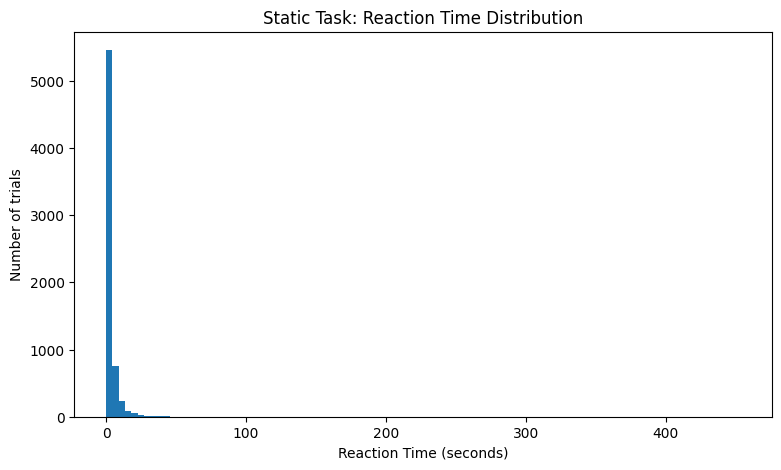

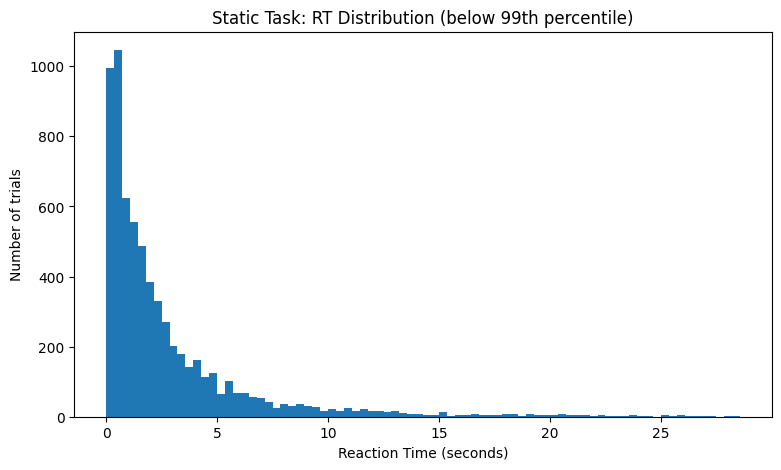

<Figure size 1000x600 with 0 Axes>

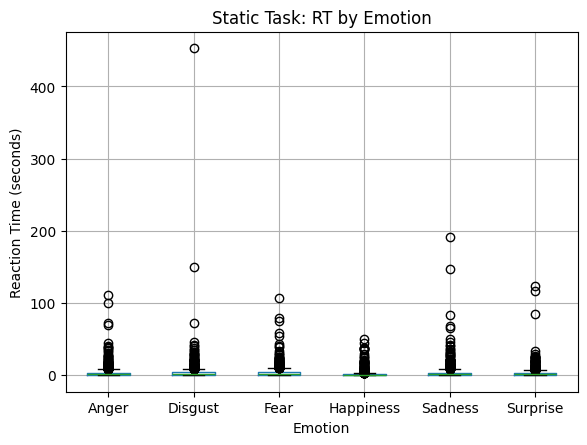


FINAL DATASET INFORMATION
Trials: 6719
Participants: 136
Emotions: 6
Groups: 6

Final response distribution:
response
1    3819
0    2900
Name: count, dtype: int64

Final emotion distribution:
emotion
Happiness    1120
Disgust      1120
Anger        1120
Surprise     1120
Sadness      1120
Fear         1119
Name: count, dtype: int64

Analysis complete.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# 1. LOAD STATIC DATA
# ============================================================

df = pd.read_excel(
    "Analysis sheet (FINAL).xlsx",
    sheet_name="Static",
    header=3
)

df.columns = df.columns.astype(str).str.strip()


# ============================================================
# 2. SELECT RELEVANT DDM VARIABLES
# ============================================================

df = df[[
    "participant",
    "category",
    "Correct_Response",
    "Correct_resp_code",
    "key_response_static.keys",
    "key_response_static.corr",
    "key_response_static.rt"
]].copy()


# ============================================================
# 3. RENAME
# ============================================================

df = df.rename(columns={
    "participant": "subj_idx",
    "category": "group",
    "Correct_Response": "emotion",
    "Correct_resp_code": "correct_code",
    "key_response_static.keys": "response_code",
    "key_response_static.corr": "correct",
    "key_response_static.rt": "rt"
})


# ============================================================
# 4. CONVERT NUMERIC VARIABLES
# ============================================================

df["rt"] = pd.to_numeric(df["rt"], errors="coerce")
df["correct_code"] = pd.to_numeric(df["correct_code"], errors="coerce")
df["response_code"] = pd.to_numeric(df["response_code"], errors="coerce")
df["correct"] = pd.to_numeric(df["correct"], errors="coerce")


# ============================================================
# 5. KEEP ONLY THE SIX EMOTIONS
# ============================================================

valid_emotions = [
    "Fear",
    "Sadness",
    "Disgust",
    "Anger",
    "Happiness",
    "Surprise"
]

df = df[df["emotion"].isin(valid_emotions)].copy()


# ============================================================
# 6. CREATE CORRECT/INCORRECT RESPONSE
# ============================================================

df["response"] = (
    df["correct_code"] == df["response_code"]
).astype(int)


# ============================================================
# 7. BASIC DATA CHECK
# ============================================================

print("\n" + "=" * 60)
print("BASIC DATA CHECK")
print("=" * 60)

print("Total trials:", len(df))
print("Total participants:", df["subj_idx"].nunique())

print("\nGroups:")
print(df["group"].value_counts())

print("\nEmotions:")
print(df["emotion"].value_counts())


# ============================================================
# 8. MISSING VALUES
# ============================================================

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

print(df[[
    "subj_idx",
    "group",
    "emotion",
    "rt",
    "correct_code",
    "response_code",
    "response"
]].isna().sum())


# ============================================================
# 9. RT SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("REACTION TIME SUMMARY")
print("=" * 60)

print(df["rt"].describe())

print("\nRT quantiles:")

print(
    df["rt"].quantile(
        [0.001, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.999]
    )
)


# ============================================================
# 10. VERY FAST RTs
# ============================================================

print("\n" + "=" * 60)
print("VERY FAST RTs")
print("=" * 60)

print("RT < 0.100 s:", (df["rt"] < 0.100).sum())
print("RT < 0.150 s:", (df["rt"] < 0.150).sum())
print("RT < 0.200 s:", (df["rt"] < 0.200).sum())
print("RT < 0.250 s:", (df["rt"] < 0.250).sum())
print("RT < 0.300 s:", (df["rt"] < 0.300).sum())


# ============================================================
# 11. VERY SLOW RTs
# ============================================================

print("\n" + "=" * 60)
print("VERY SLOW RTs")
print("=" * 60)

print("RT > 5 s:", (df["rt"] > 5).sum())
print("RT > 10 s:", (df["rt"] > 10).sum())
print("RT > 15 s:", (df["rt"] > 15).sum())
print("RT > 20 s:", (df["rt"] > 20).sum())


# ============================================================
# 12. ACCURACY
# ============================================================

print("\n" + "=" * 60)
print("OVERALL ACCURACY")
print("=" * 60)

accuracy = df["response"].mean()

print(f"Overall accuracy: {accuracy:.3f}")
print(f"Overall accuracy: {accuracy * 100:.2f}%")


# ============================================================
# 13. ACCURACY BY EMOTION
# ============================================================

print("\n" + "=" * 60)
print("ACCURACY BY EMOTION")
print("=" * 60)

emotion_accuracy = (
    df.groupby("emotion")["response"]
    .agg(["count", "mean", "sum"])
)

emotion_accuracy["accuracy_percent"] = (
    emotion_accuracy["mean"] * 100
)

print(emotion_accuracy)


# ============================================================
# 14. ACCURACY BY GROUP
# ============================================================

print("\n" + "=" * 60)
print("ACCURACY BY GROUP")
print("=" * 60)

group_accuracy = (
    df.groupby("group")["response"]
    .agg(["count", "mean"])
)

group_accuracy["accuracy_percent"] = (
    group_accuracy["mean"] * 100
)

print(group_accuracy)


# ============================================================
# 15. ACCURACY: GROUP × EMOTION
# ============================================================

print("\n" + "=" * 60)
print("ACCURACY: GROUP × EMOTION")
print("=" * 60)

group_emotion_accuracy = (
    df.groupby(["group", "emotion"])["response"]
    .agg(["count", "mean"])
)

group_emotion_accuracy["accuracy_percent"] = (
    group_emotion_accuracy["mean"] * 100
)

print(group_emotion_accuracy)


# ============================================================
# 16. TRIALS PER PARTICIPANT
# ============================================================

print("\n" + "=" * 60)
print("TRIALS PER PARTICIPANT")
print("=" * 60)

trials_per_subject = (
    df.groupby("subj_idx")
    .size()
)

print(trials_per_subject.describe())

print("\nParticipants with unusually few trials:")

print(
    trials_per_subject[
        trials_per_subject < trials_per_subject.median() * 0.5
    ]
)


# ============================================================
# 17. TRIALS PER PARTICIPANT × EMOTION
# ============================================================

print("\n" + "=" * 60)
print("TRIALS PER PARTICIPANT × EMOTION")
print("=" * 60)

trials_subject_emotion = (
    df.groupby(["subj_idx", "emotion"])
    .size()
    .unstack(fill_value=0)
)

print(trials_subject_emotion)


# ============================================================
# 18. CHECK WHETHER EVERY PARTICIPANT HAS ALL EMOTIONS
# ============================================================

missing_emotions = (
    trials_subject_emotion == 0
).sum(axis=1)

print("\nParticipants missing one or more emotions:")
print(
    missing_emotions[
        missing_emotions > 0
    ]
)


# ============================================================
# 19. PARTICIPANT-LEVEL ACCURACY
# ============================================================

participant_accuracy = (
    df.groupby("subj_idx")["response"]
    .agg(["count", "mean"])
)

participant_accuracy["accuracy_percent"] = (
    participant_accuracy["mean"] * 100
)

print("\n" + "=" * 60)
print("PARTICIPANT-LEVEL ACCURACY")
print("=" * 60)

print(participant_accuracy.describe())


# ============================================================
# 20. PARTICIPANTS WITH EXTREME ACCURACY
# ============================================================

print("\nParticipants with accuracy < 50%:")

print(
    participant_accuracy[
        participant_accuracy["mean"] < 0.50
    ]
)

print("\nParticipants with accuracy > 95%:")

print(
    participant_accuracy[
        participant_accuracy["mean"] > 0.95
    ]
)


# ============================================================
# 21. PARTICIPANTS WITH NO ERRORS
# ============================================================

print("\n" + "=" * 60)
print("PARTICIPANTS WITH NO ERRORS")
print("=" * 60)

no_error_subjects = (
    df.groupby("subj_idx")["response"]
    .mean()
)

print(
    no_error_subjects[
        no_error_subjects == 1
    ]
)


# ============================================================
# 22. PARTICIPANTS WITH NO CORRECT RESPONSES
# ============================================================

print("\n" + "=" * 60)
print("PARTICIPANTS WITH NO CORRECT RESPONSES")
print("=" * 60)

no_correct_subjects = (
    no_error_subjects[
        no_error_subjects == 0
    ]
)

print(no_correct_subjects)


# ============================================================
# 23. RT BY EMOTION
# ============================================================

print("\n" + "=" * 60)
print("RT BY EMOTION")
print("=" * 60)

rt_emotion = (
    df.groupby("emotion")["rt"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

print(rt_emotion)


# ============================================================
# 24. RT BY GROUP
# ============================================================

print("\n" + "=" * 60)
print("RT BY GROUP")
print("=" * 60)

rt_group = (
    df.groupby("group")["rt"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

print(rt_group)


# ============================================================
# 25. CORRECT VS INCORRECT RT
# ============================================================

print("\n" + "=" * 60)
print("RT: CORRECT VS INCORRECT")
print("=" * 60)

rt_correct = (
    df.groupby("response")["rt"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

print(rt_correct)


# ============================================================
# 26. FIND EXTREME RT TRIALS
# ============================================================

print("\n" + "=" * 60)
print("EXTREME RT TRIALS")
print("=" * 60)

print("\nFastest 10 trials:")
print(
    df.nsmallest(10, "rt")[[
        "subj_idx",
        "group",
        "emotion",
        "rt",
        "response"
    ]]
)

print("\nSlowest 10 trials:")
print(
    df.nlargest(10, "rt")[[
        "subj_idx",
        "group",
        "emotion",
        "rt",
        "response"
    ]]
)


# ============================================================
# 27. RT HISTOGRAM
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    df["rt"],
    bins=100
)

plt.xlabel("Reaction Time (seconds)")
plt.ylabel("Number of trials")
plt.title("Static Task: Reaction Time Distribution")

plt.show()


# ============================================================
# 28. RT HISTOGRAM WITHOUT EXTREME TAIL
# ============================================================

plt.figure(figsize=(9, 5))

plt.hist(
    df.loc[df["rt"] < df["rt"].quantile(0.99), "rt"],
    bins=80
)

plt.xlabel("Reaction Time (seconds)")
plt.ylabel("Number of trials")
plt.title("Static Task: RT Distribution (below 99th percentile)")

plt.show()


# ============================================================
# 29. RT BY EMOTION
# ============================================================

plt.figure(figsize=(10, 6))

df.boxplot(
    column="rt",
    by="emotion"
)

plt.xlabel("Emotion")
plt.ylabel("Reaction Time (seconds)")
plt.title("Static Task: RT by Emotion")

plt.suptitle("")

plt.show()


# ============================================================
# 30. FINAL DDM DATASET
# ============================================================

print("\n" + "=" * 60)
print("FINAL DATASET INFORMATION")
print("=" * 60)

print("Trials:", len(df))
print("Participants:", df["subj_idx"].nunique())
print("Emotions:", df["emotion"].nunique())
print("Groups:", df["group"].nunique())

print("\nFinal response distribution:")
print(df["response"].value_counts())

print("\nFinal emotion distribution:")
print(df["emotion"].value_counts())

print("\nAnalysis complete.")

In [4]:
import pandas as pd
import numpy as np

# ============================================================
# 1. LOAD STATIC DATA
# ============================================================

df = pd.read_excel(
    "Analysis sheet (FINAL).xlsx",
    sheet_name="Static",
    header=3
)

df.columns = df.columns.astype(str).str.strip()


# ============================================================
# 2. SELECT VARIABLES NEEDED FOR DDM
# ============================================================

df = df[[
    "participant",
    "category",
    "Correct_Response",
    "Correct_resp_code",
    "key_response_static.keys",
    "key_response_static.corr",
    "key_response_static.rt"
]].copy()


# ============================================================
# 3. RENAME VARIABLES
# ============================================================

df = df.rename(columns={
    "participant": "subj_idx",
    "category": "group",
    "Correct_Response": "emotion",
    "Correct_resp_code": "correct_code",
    "key_response_static.keys": "response_code",
    "key_response_static.corr": "correct_original",
    "key_response_static.rt": "rt"
})


# ============================================================
# 4. CONVERT NUMERIC VARIABLES
# ============================================================

df["rt"] = pd.to_numeric(df["rt"], errors="coerce")
df["correct_code"] = pd.to_numeric(
    df["correct_code"], errors="coerce"
)
df["response_code"] = pd.to_numeric(
    df["response_code"], errors="coerce"
)


# ============================================================
# 5. KEEP ONLY SIX EMOTIONS
# ============================================================

valid_emotions = [
    "Fear",
    "Sadness",
    "Disgust",
    "Anger",
    "Happiness",
    "Surprise"
]

df = df[
    df["emotion"].isin(valid_emotions)
].copy()


# ============================================================
# 6. CREATE BINARY RESPONSE
#
# 1 = CORRECT
# 0 = INCORRECT
# ============================================================

df["response"] = (
    df["correct_code"] == df["response_code"]
).astype(int)


# ============================================================
# 7. STANDARDIZE GROUP NAMES
#
# ADHD and ADHD-H remain separate
# Autism/AUTISM -> AUTISM
# Normal/NORMAL -> NORMAL
# ============================================================

df["group"] = df["group"].astype(str).str.strip()

df["group"] = df["group"].replace({
    "Autism": "AUTISM",
    "AUTISM": "AUTISM",
    "Normal": "NORMAL",
    "NORMAL": "NORMAL",
    "ADHD": "ADHD",
    "ADHD-H": "ADHD-H"
})


# ============================================================
# 8. REPORT DATA BEFORE RT FILTERING
# ============================================================

print("\n" + "=" * 60)
print("BEFORE RT FILTERING")
print("=" * 60)

print("Trials:", len(df))
print("Participants:", df["subj_idx"].nunique())

print("\nGroups:")
print(df["group"].value_counts())

print("\nEmotions:")
print(df["emotion"].value_counts())


# ============================================================
# 9. REMOVE MISSING RT
# ============================================================

missing_rt = df["rt"].isna().sum()

print("\nMissing RT trials:", missing_rt)

df = df.dropna(subset=["rt"]).copy()


# ============================================================
# 10. REMOVE VERY FAST RESPONSES
#
# RT < 0.2 seconds
# ============================================================

fast_trials = (df["rt"] < 0.2).sum()

print("RT < 0.2 s:", fast_trials)

df = df[df["rt"] >= 0.2].copy()


# ============================================================
# 11. REMOVE VERY SLOW RESPONSES
#
# RT > 10 seconds
# ============================================================

slow_trials = (df["rt"] > 10).sum()

print("RT > 10 s:", slow_trials)

df = df[df["rt"] <= 10].copy()


# ============================================================
# 12. FINAL CLEAN DATASET
# ============================================================

ddm_clean = df[[
    "subj_idx",
    "group",
    "emotion",
    "rt",
    "response"
]].copy()


# ============================================================
# 13. FINAL DATA SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("FINAL CLEAN DDM DATASET")
print("=" * 60)

print("Final trials:", len(ddm_clean))
print("Final participants:", ddm_clean["subj_idx"].nunique())

print("\nGroups:")
print(ddm_clean["group"].value_counts())

print("\nEmotions:")
print(ddm_clean["emotion"].value_counts())

print("\nResponse:")
print(
    ddm_clean["response"]
    .value_counts()
    .sort_index()
)

print("\nAccuracy:")
print(
    ddm_clean["response"].mean() * 100,
    "%"
)


# ============================================================
# 14. TRIALS PER PARTICIPANT
# ============================================================

trials_subject = (
    ddm_clean
    .groupby("subj_idx")
    .size()
)

print("\n" + "=" * 60)
print("TRIALS PER PARTICIPANT")
print("=" * 60)

print(trials_subject.describe())


# ============================================================
# 15. CORRECT / INCORRECT PER PARTICIPANT
# ============================================================

subject_response = (
    ddm_clean
    .groupby(["subj_idx", "response"])
    .size()
    .unstack(fill_value=0)
)

# Make sure both columns exist
if 0 not in subject_response.columns:
    subject_response[0] = 0

if 1 not in subject_response.columns:
    subject_response[1] = 0

subject_response = subject_response[[0, 1]]

subject_response.columns = [
    "incorrect_trials",
    "correct_trials"
]

subject_response["total_trials"] = (
    subject_response["incorrect_trials"]
    + subject_response["correct_trials"]
)

subject_response["accuracy"] = (
    subject_response["correct_trials"]
    / subject_response["total_trials"]
)


print("\n" + "=" * 60)
print("PARTICIPANT RESPONSE INFORMATION")
print("=" * 60)

print(subject_response.describe())


# ============================================================
# 16. CHECK PARTICIPANTS WITH ZERO ERRORS
# ============================================================

zero_error = subject_response[
    subject_response["incorrect_trials"] == 0
]

print("\nParticipants with ZERO errors:")
print(len(zero_error))

if len(zero_error) > 0:
    print(zero_error)


# ============================================================
# 17. CHECK PARTICIPANTS WITH ZERO CORRECT RESPONSES
# ============================================================

zero_correct = subject_response[
    subject_response["correct_trials"] == 0
]

print("\nParticipants with ZERO correct responses:")
print(len(zero_correct))

if len(zero_correct) > 0:
    print(zero_correct)


# ============================================================
# 18. TRIALS PER PARTICIPANT × EMOTION
# ============================================================

subject_emotion = (
    ddm_clean
    .groupby(["subj_idx", "emotion"])
    .size()
    .unstack(fill_value=0)
)

print("\n" + "=" * 60)
print("TRIALS PER PARTICIPANT × EMOTION")
print("=" * 60)

print(subject_emotion.describe())


# ============================================================
# 19. ACCURACY BY EMOTION
# ============================================================

emotion_accuracy = (
    ddm_clean
    .groupby("emotion")["response"]
    .agg(["count", "mean"])
)

emotion_accuracy["accuracy_percent"] = (
    emotion_accuracy["mean"] * 100
)

print("\n" + "=" * 60)
print("ACCURACY BY EMOTION")
print("=" * 60)

print(emotion_accuracy)


# ============================================================
# 20. ACCURACY BY GROUP
# ============================================================

group_accuracy = (
    ddm_clean
    .groupby("group")["response"]
    .agg(["count", "mean"])
)

group_accuracy["accuracy_percent"] = (
    group_accuracy["mean"] * 100
)

print("\n" + "=" * 60)
print("ACCURACY BY GROUP")
print("=" * 60)

print(group_accuracy)


# ============================================================
# 21. RT SUMMARY AFTER CLEANING
# ============================================================

print("\n" + "=" * 60)
print("RT AFTER CLEANING")
print("=" * 60)

print(ddm_clean["rt"].describe())


# ============================================================
# 22. RT BY EMOTION
# ============================================================

print("\n" + "=" * 60)
print("RT BY EMOTION")
print("=" * 60)

print(
    ddm_clean
    .groupby("emotion")["rt"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
)


# ============================================================
# 23. RT BY GROUP
# ============================================================

print("\n" + "=" * 60)
print("RT BY GROUP")
print("=" * 60)

print(
    ddm_clean
    .groupby("group")["rt"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
)


# ============================================================
# 24. SAVE CLEAN DATA
# ============================================================

ddm_clean.to_csv(
    "Static_DDM_Clean.csv",
    index=False
)

print("\n" + "=" * 60)
print("SAVED")
print("=" * 60)

print("Static_DDM_Clean.csv")


BEFORE RT FILTERING
Trials: 6719
Participants: 136

Groups:
group
ADHD      3264
NORMAL    2351
AUTISM    1056
ADHD-H      48
Name: count, dtype: int64

Emotions:
emotion
Happiness    1120
Disgust      1120
Anger        1120
Surprise     1120
Sadness      1120
Fear         1119
Name: count, dtype: int64

Missing RT trials: 23
RT < 0.2 s: 213
RT > 10 s: 424

FINAL CLEAN DDM DATASET
Final trials: 6059
Final participants: 136

Groups:
group
ADHD      2909
NORMAL    2259
AUTISM     845
ADHD-H      46
Name: count, dtype: int64

Emotions:
emotion
Surprise     1023
Anger        1015
Fear         1009
Disgust      1008
Sadness      1003
Happiness    1001
Name: count, dtype: int64

Response:
response
0    2552
1    3507
Name: count, dtype: int64

Accuracy:
57.88083842218188 %

TRIALS PER PARTICIPANT
count    136.000000
mean      44.551471
std        7.959918
min       28.000000
25%       41.000000
50%       44.500000
75%       47.000000
max       91.000000
dtype: float64

PARTICIPANT RESPONSE 

In [5]:
import numpy as np
import pandas as pd

from pyddm import (
    Model,
    Fittable,
    Sample,
    fit_adjust_model,
    LossRobustLikelihood
)

from pyddm.models import (
    DriftConstant,
    NoiseConstant,
    BoundConstant,
    OverlayChain,
    OverlayNonDecision,
    OverlayUniformMixture
)


# ============================================================
# LOAD CLEANED STATIC DATA
# ============================================================

ddm_data = pd.read_csv(
    "Static_DDM_Clean.csv"
)

# Rename columns
ddm_data = ddm_data.rename(columns={
    "subj_idx": "subject",
    "response": "correct"
})

# Keep required columns
ddm_data = ddm_data[
    ["subject", "group", "emotion", "rt", "correct"]
].copy()

# Ensure correct is binary
ddm_data["correct"] = ddm_data["correct"].astype(int)

# Remove missing values
ddm_data = ddm_data.dropna(
    subset=["subject", "rt", "correct"]
)

print("Total trials:", len(ddm_data))
print("Total subjects:", ddm_data["subject"].nunique())
print("Maximum RT:", ddm_data["rt"].max())


# ============================================================
# DDM FUNCTION
# ============================================================

def fit_ddm_subject(rt_arr, correct_arr, subject_id=None):

    try:

        # Create PyDDM sample
        sample = Sample.from_numpy_array(
            np.column_stack([
                rt_arr,
                correct_arr.astype(int)
            ])
        )

        # ----------------------------------------------------
        # 3-PARAMETER DDM
        # ----------------------------------------------------

        model = Model(

            name=f"subj_{subject_id}",

            # Drift rate
            # Allow both positive and negative drift
            drift=DriftConstant(
                drift=Fittable(
                    minval=-5.0,
                    maxval=5.0
                )
            ),

            # Diffusion noise fixed at 1
            noise=NoiseConstant(
                noise=1.0
            ),

            # Boundary separation
            bound=BoundConstant(
                B=Fittable(
                    minval=0.3,
                    maxval=2.5
                )
            ),

            # Non-decision time + 2% lapse
            overlay=OverlayChain(
                overlays=[

                    OverlayNonDecision(
                        nondectime=Fittable(
                            minval=0.1,
                            maxval=0.7
                        )
                    ),

                    OverlayUniformMixture(
                        umixturecoef=0.02
                    )
                ]
            ),

            # Numerical settings
            dx=0.01,
            dt=0.01,

            # IMPORTANT:
            # Must exceed maximum RT (~10 s)
            T_dur=10.5
        )

        # ----------------------------------------------------
        # FIT
        # ----------------------------------------------------

        fit_adjust_model(
            sample,
            model,
            fitting_method="differential_evolution",
            lossfunction=LossRobustLikelihood,
            verbose=False
        )

        # ----------------------------------------------------
        # EXTRACT PARAMETERS
        # ----------------------------------------------------

        params = model.get_model_parameters()

        return {
            "v": float(params[0]),
            "a": float(params[1]),
            "t": float(params[2])
        }

    except Exception as e:

        print(
            f"Subject {subject_id} failed: {e}"
        )

        return {
            "v": np.nan,
            "a": np.nan,
            "t": np.nan
        }


# ============================================================
# FIT ALL SUBJECTS
# ============================================================

ddm_records = []

subjects = ddm_data["subject"].unique()

print(
    f"\nFitting DDM for {len(subjects)} subjects..."
)

for i, sid in enumerate(subjects):

    # Select participant
    sub = ddm_data[
        ddm_data["subject"] == sid
    ]

    # Fit DDM
    res = fit_ddm_subject(
        sub["rt"].values,
        sub["correct"].values,
        sid
    )

    # Add participant information
    res["subject"] = sid
    res["group"] = sub["group"].iloc[0]
    res["n_trials"] = len(sub)
    res["accuracy"] = sub["correct"].mean()

    ddm_records.append(res)

    # Progress
    if (i + 1) % 10 == 0:
        print(
            f"{i + 1}/{len(subjects)} subjects fitted..."
        )


# ============================================================
# CREATE FINAL DDM DATASET
# ============================================================

ddm_params_raw = pd.DataFrame(ddm_records)

ddm_params_raw = ddm_params_raw[
    [
        "subject",
        "group",
        "n_trials",
        "accuracy",
        "v",
        "a",
        "t"
    ]
]


# ============================================================
# FITTING SUCCESS
# ============================================================

ok = ddm_params_raw[
    ["v", "a", "t"]
].notna().all(axis=1).sum()

failed = len(ddm_params_raw) - ok

print("\n========================================")
print("DDM FITTING COMPLETE")
print("========================================")

print(
    f"Successfully fitted: {ok}/{len(subjects)}"
)

print(
    f"Failed: {failed}"
)

print("\nParameter summary:")

print(
    ddm_params_raw[
        ["v", "a", "t"]
    ].describe()
)


# ============================================================
# GROUP SUMMARY
# ============================================================

print("\nGroup-wise DDM parameters:")

print(
    ddm_params_raw
    .groupby("group")[["v", "a", "t"]]
    .agg(["mean", "std", "count"])
)


# ============================================================
# SAVE
# ============================================================

ddm_params_raw.to_csv(
    "Static_DDM_Subject_Parameters.csv",
    index=False
)

print(
    "\nSaved as:"
    "\nStatic_DDM_Subject_Parameters.csv"
)

Total trials: 6059
Total subjects: 136
Maximum RT: 9.99684450030326

Fitting DDM for 136 subjects...


Info: Params [0.05116308 1.21261605 0.10679702] gave 212.67452896615015
Info: Params [-0.10963114  1.17275973  0.10527546] gave 218.20425244012313
Info: Params [-0.15912889  1.34708008  0.10429813] gave 126.75119301604411
Info: Params [-0.00571499  1.51645331  0.10704207] gave 114.78183357265107
Info: Params [0.31748451 1.04480352 0.10363209] gave 92.55308273159638
Info: Params [0.12618413 1.67434826 0.10508384] gave 99.53332837425464
Info: Params [-0.48878442  1.1062385   0.1086314 ] gave 110.18173866236447
Info: Params [-0.11609909  1.22109628  0.10686862] gave 105.37832519383818
Info: Params [0.27356075 1.25445024 0.13332824] gave 88.1656694717349
Info: Params [0.30884412 0.93172177 0.10807674] gave 80.72949952180757


10/136 subjects fitted...


Info: Params [-0.10234749  1.68119353  0.10491331] gave 141.58384214016226
Info: Params [0.31773728 1.11713114 0.1032367 ] gave 89.77032476078077
Info: Params [0.05020195 1.05778806 0.10177459] gave 106.25778846767257
Info: Params [0.28185829 1.76833965 0.2265109 ] gave 120.01793448937448
Info: Params [-0.1203498   1.32751309  0.10106893] gave 104.50813753729278
Info: Params [0.11606832 1.17382985 0.10338393] gave 118.69631503535986
Info: Params [-0.11535327  1.16929466  0.10421762] gave 120.08208427513564
Info: Params [0.61887482 0.85616456 0.13835631] gave 55.17489364197812
Info: Params [-0.03768115  1.40383439  0.10216649] gave 123.1355546332237
Info: Params [0.08627606 1.52309046 0.10756208] gave 110.77640250653604


20/136 subjects fitted...


...

120/136 subjects fitted...


Info: Params [-0.05561855  1.1536925   0.10859866] gave 119.77776265830725
Info: Params [0.06973392 1.53444557 0.10992921] gave 121.13588191606382
Info: Params [0.13644578 1.71493899 0.10323632] gave 106.72682319576438
Info: Params [-0.03338087  1.80439035  0.4175561 ] gave 106.55040289996921
Info: Params [0.25236811 0.94764367 0.21126951] gave 85.92949593185487
Info: Params [0.1003968  1.17149969 0.10823228] gave 128.89736012397637
Info: Params [0.56071878 1.15152917 0.1073274 ] gave 103.47519453539493
Info: Params [0.16627894 1.22650531 0.10374111] gave 116.53210110318844
Info: Params [-0.04553108  1.08821911  0.10415334] gave 119.19705194199548
Info: Params [0.31309191 1.02358081 0.10621653] gave 100.33898840752855


130/136 subjects fitted...


Info: Params [-0.04671098  1.01403288  0.10170954] gave 89.87390160251954
Info: Params [0.01392435 1.14397679 0.10721315] gave 100.37492963625886
Info: Params [0.42749461 0.79104136 0.10069637] gave 83.84700786634274
Info: Params [0.07788007 1.42249244 0.10617357] gave 116.8566061585794
Info: Params [0.03067862 1.06829783 0.10658258] gave 100.65668044210928
Info: Params [0.0595843  1.24191566 0.10217751] gave 106.43481267924912



DDM FITTING COMPLETE
Successfully fitted: 136/136
Failed: 0

Parameter summary:
                v           a           t
count  136.000000  136.000000  136.000000
mean     0.160641    1.247345    0.129821
std      0.230722    0.287255    0.089357
min     -0.488784    0.631523    0.100122
25%      0.009946    1.055360    0.103924
50%      0.139367    1.215472    0.106929
75%      0.270886    1.437249    0.109261
max      1.283640    2.003570    0.690316

Group-wise DDM parameters:
               v                         a                         t  \
            mean       std count      mean       std count      mean   
group                                                                  
ADHD    0.148178  0.227401    67  1.234739  0.288347    67  0.126767   
ADHD-H  0.142938       NaN     1  1.445482       NaN     1  0.105857   
AUTISM  0.049006  0.101827    20  1.452956  0.342693    20  0.144491   
NORMAL  0.224921  0.257572    48  1.175141  0.220016    48  0.128472   

        

In [6]:
print(sorted(df["group"].dropna().unique()))

['ADHD', 'ADHD-H', 'AUTISM', 'NORMAL']


In [8]:
print([x for x in globals() if "result" in x.lower() or "ddm" in x.lower()])

['binary_ddm', 'ddm_clean', 'ddm_data', 'fit_ddm_subject', 'ddm_records', 'ddm_params_raw']


In [9]:
print("ddm_params_raw:")
print(type(ddm_params_raw))
print(ddm_params_raw)

print("\n" + "="*60)

print("ddm_records:")
print(type(ddm_records))
print(ddm_records)

ddm_params_raw:
<class 'pandas.core.frame.DataFrame'>
       subject   group  n_trials  accuracy         v         a         t
0        manit    ADHD        77  0.519481  0.051163  1.212616  0.106797
1      harshit  NORMAL        91  0.417582 -0.109631  1.172760  0.105275
2       aditya    ADHD        41  0.341463 -0.159129  1.347080  0.104298
3     amrit(C)    ADHD        44  0.500000 -0.005715  1.516453  0.107042
4    amrit raj  NORMAL        44  0.681818  0.317485  1.044804  0.103632
..         ...     ...       ...       ...       ...       ...       ...
131    chunmun  NORMAL        42  0.500000  0.013924  1.143977  0.107213
132     harman    ADHD        41  0.634146  0.427495  0.791041  0.100696
133     hammad    ADHD        36  0.583333  0.077880  1.422492  0.106174
134      tanay    ADHD        33  0.545455  0.030679  1.068298  0.106583
135     tavraj    ADHD        37  0.567568  0.059584  1.241916  0.102178

[136 rows x 7 columns]

ddm_records:
<class 'list'>
[{'v': 0.05116308

In [10]:
print("ddm_params_raw")
print(type(ddm_params_raw))

if hasattr(ddm_params_raw, "shape"):
    print("Shape:", ddm_params_raw.shape)

if hasattr(ddm_params_raw, "columns"):
    print("Columns:", ddm_params_raw.columns.tolist())
    print(ddm_params_raw.head())

print("\n" + "="*60)

print("ddm_records")
print(type(ddm_records))

if hasattr(ddm_records, "shape"):
    print("Shape:", ddm_records.shape)

if hasattr(ddm_records, "columns"):
    print("Columns:", ddm_records.columns.tolist())
    print(ddm_records.head())

ddm_params_raw
<class 'pandas.core.frame.DataFrame'>
Shape: (136, 7)
Columns: ['subject', 'group', 'n_trials', 'accuracy', 'v', 'a', 't']
     subject   group  n_trials  accuracy         v         a         t
0      manit    ADHD        77  0.519481  0.051163  1.212616  0.106797
1    harshit  NORMAL        91  0.417582 -0.109631  1.172760  0.105275
2     aditya    ADHD        41  0.341463 -0.159129  1.347080  0.104298
3   amrit(C)    ADHD        44  0.500000 -0.005715  1.516453  0.107042
4  amrit raj  NORMAL        44  0.681818  0.317485  1.044804  0.103632

ddm_records
<class 'list'>


Number of fitted participants: 136

Parameter summary:
                v           a           t
count  136.000000  136.000000  136.000000
mean     0.160641    1.247345    0.129821
std      0.230722    0.287255    0.089357
min     -0.488784    0.631523    0.100122
25%      0.009946    1.055360    0.103924
50%      0.139367    1.215472    0.106929
75%      0.270886    1.437249    0.109261
max      1.283640    2.003570    0.690316

Participants close to parameter bounds:
v: 0
a: 0
t: 56

Boundary percentages:
v: 0.0 %
a: 0.0 %
t: 41.18 %

Participants close to ANY parameter boundary:
56
         subject  group  n_trials  accuracy         v        a        t
         harshit NORMAL        91  0.417582 -0.109631 1.172760 0.105275
          aditya   ADHD        41  0.341463 -0.159129 1.347080 0.104298
       amrit raj NORMAL        44  0.681818  0.317485 1.044804 0.103632
         ansh(C)   ADHD        38  0.605263  0.126184 1.674348 0.105084
       goranshi  NORMAL        43  0.395349 -0.1

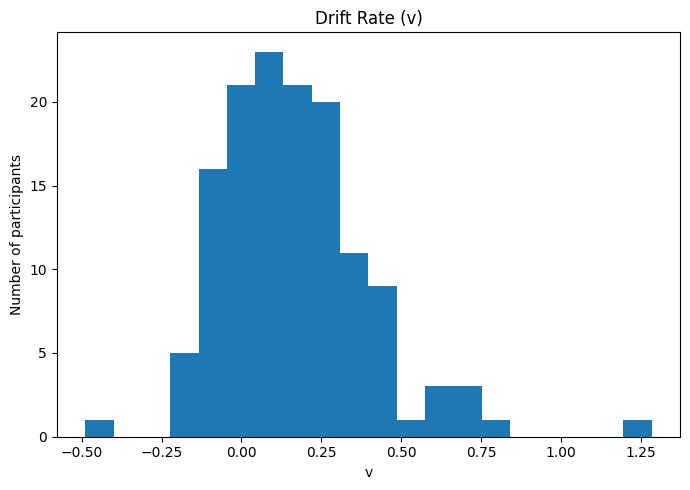

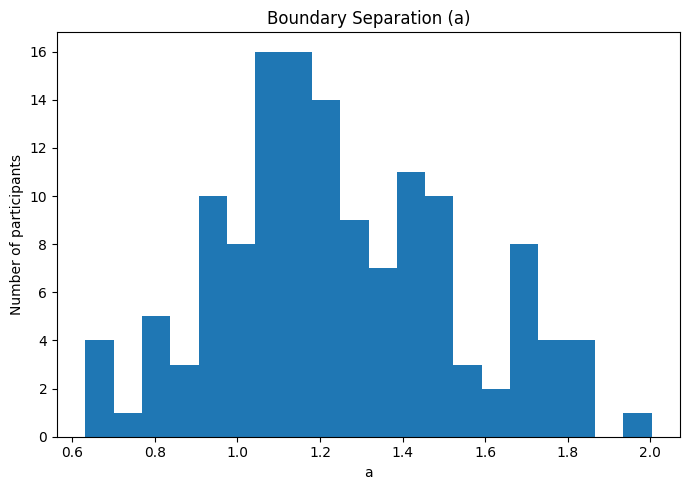

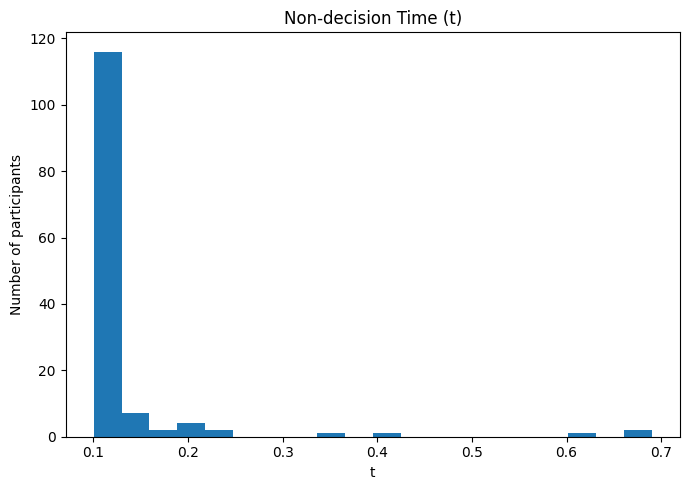

C:\Users\abhia\AppData\Local\Temp\ipykernel_27976\3066015846.py:203: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=groups)


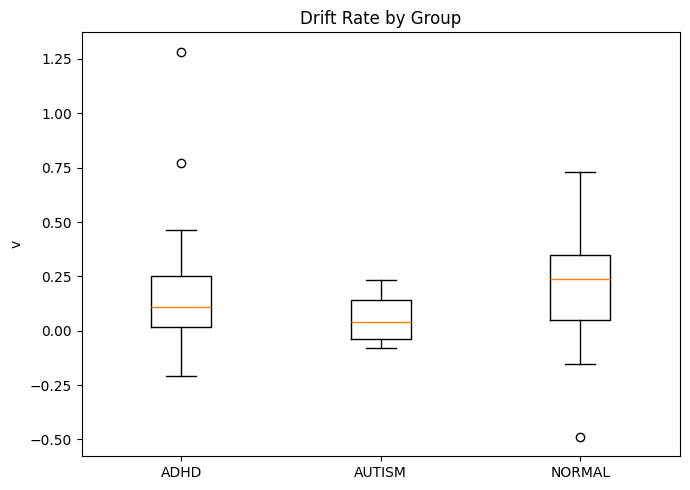

C:\Users\abhia\AppData\Local\Temp\ipykernel_27976\3066015846.py:203: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=groups)


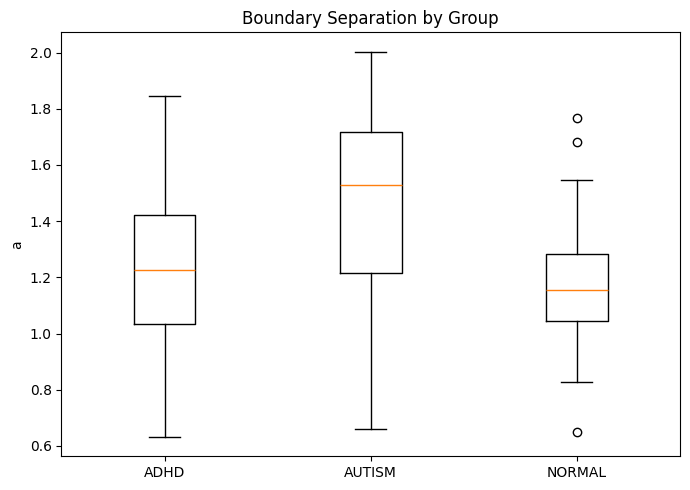

C:\Users\abhia\AppData\Local\Temp\ipykernel_27976\3066015846.py:203: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=groups)


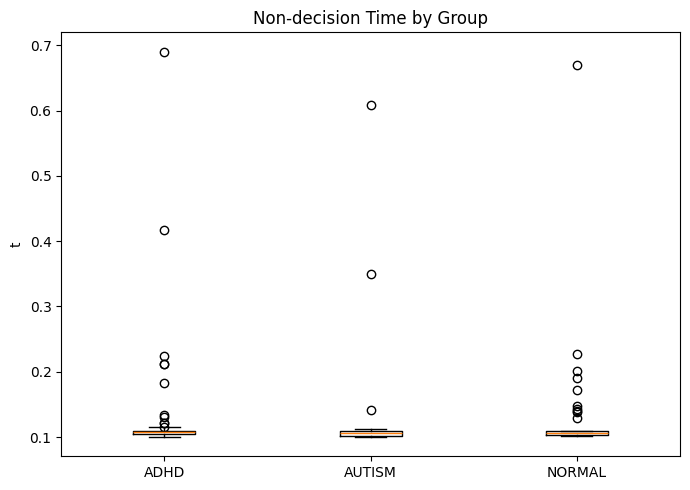

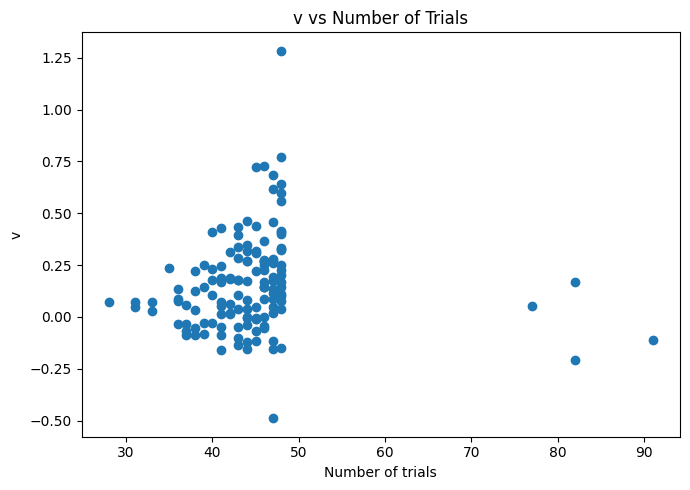

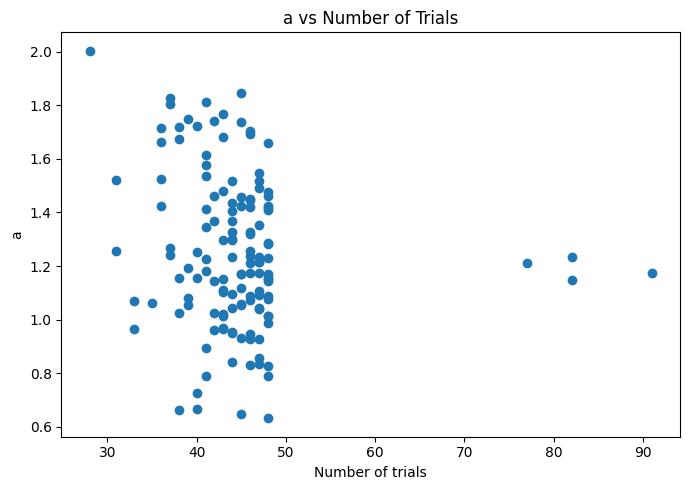

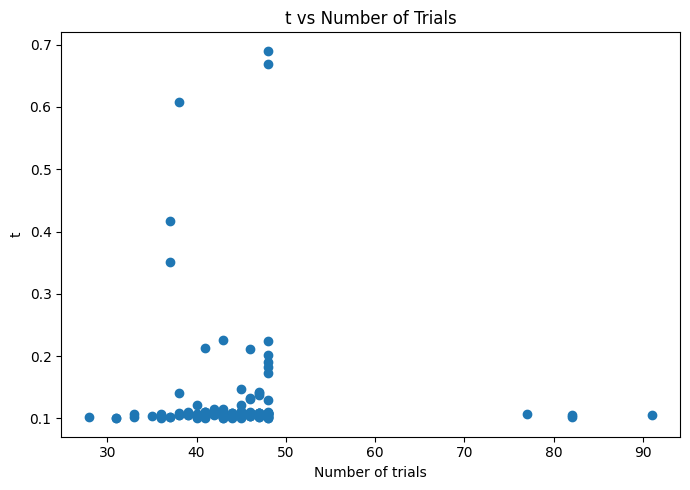

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# DDM QUALITY CONTROL
# ============================================================

qc = ddm_params_raw.copy()

print("Number of fitted participants:", len(qc))

# ------------------------------------------------------------
# 1. Basic parameter summary
# ------------------------------------------------------------

print("\nParameter summary:")
print(qc[["v", "a", "t"]].describe())

# ------------------------------------------------------------
# 2. Check parameters close to model bounds
# ------------------------------------------------------------

v_min, v_max = -5.0, 5.0
a_min, a_max = 0.3, 2.5
t_min, t_max = 0.1, 0.7

def boundary_check(series, lower, upper):
    margin = 0.01 * (upper - lower)
    return (series <= lower + margin) | (series >= upper - margin)

qc["v_boundary"] = boundary_check(qc["v"], v_min, v_max)
qc["a_boundary"] = boundary_check(qc["a"], a_min, a_max)
qc["t_boundary"] = boundary_check(qc["t"], t_min, t_max)

print("\nParticipants close to parameter bounds:")
print("v:", qc["v_boundary"].sum())
print("a:", qc["a_boundary"].sum())
print("t:", qc["t_boundary"].sum())

print("\nBoundary percentages:")
print("v:", round(qc["v_boundary"].mean() * 100, 2), "%")
print("a:", round(qc["a_boundary"].mean() * 100, 2), "%")
print("t:", round(qc["t_boundary"].mean() * 100, 2), "%")

# ------------------------------------------------------------
# 3. Participants close to ANY boundary
# ------------------------------------------------------------

boundary_subjects = qc[
    qc["v_boundary"] |
    qc["a_boundary"] |
    qc["t_boundary"]
]

print("\nParticipants close to ANY parameter boundary:")
print(len(boundary_subjects))

if len(boundary_subjects) > 0:
    print(
        boundary_subjects[
            ["subject", "group", "n_trials", "accuracy", "v", "a", "t"]
        ].to_string(index=False)
    )

# ------------------------------------------------------------
# 4. Extreme parameter values
# ------------------------------------------------------------

print("\n" + "="*60)
print("LOWEST 5 DRIFT RATES")
print("="*60)

print(
    qc.nsmallest(5, "v")[
        ["subject", "group", "n_trials", "accuracy", "v", "a", "t"]
    ].to_string(index=False)
)

print("\n" + "="*60)
print("HIGHEST 5 DRIFT RATES")
print("="*60)

print(
    qc.nlargest(5, "v")[
        ["subject", "group", "n_trials", "accuracy", "v", "a", "t"]
    ].to_string(index=False)
)

print("\n" + "="*60)
print("LOWEST 5 BOUNDARY SEPARATIONS")
print("="*60)

print(
    qc.nsmallest(5, "a")[
        ["subject", "group", "n_trials", "accuracy", "v", "a", "t"]
    ].to_string(index=False)
)

print("\n" + "="*60)
print("HIGHEST 5 BOUNDARY SEPARATIONS")
print("="*60)

print(
    qc.nlargest(5, "a")[
        ["subject", "group", "n_trials", "accuracy", "v", "a", "t"]
    ].to_string(index=False)
)

print("\n" + "="*60)
print("LOWEST 5 NON-DECISION TIMES")
print("="*60)

print(
    qc.nsmallest(5, "t")[
        ["subject", "group", "n_trials", "accuracy", "v", "a", "t"]
    ].to_string(index=False)
)

print("\n" + "="*60)
print("HIGHEST 5 NON-DECISION TIMES")
print("="*60)

print(
    qc.nlargest(5, "t")[
        ["subject", "group", "n_trials", "accuracy", "v", "a", "t"]
    ].to_string(index=False)
)

# ------------------------------------------------------------
# 5. Non-decision time concentration near bounds
# ------------------------------------------------------------

print("\n" + "="*60)
print("NON-DECISION TIME BOUNDARY CHECK")
print("="*60)

lower_t = (qc["t"] <= 0.105).sum()
upper_t = (qc["t"] >= 0.695).sum()

print("t <= 0.105 s:", lower_t)
print("Percentage:", round(lower_t / len(qc) * 100, 2), "%")

print("t >= 0.695 s:", upper_t)
print("Percentage:", round(upper_t / len(qc) * 100, 2), "%")

# ------------------------------------------------------------
# 6. Trial count
# ------------------------------------------------------------

print("\n" + "="*60)
print("TRIAL COUNT")
print("="*60)

print(qc["n_trials"].describe())

# ------------------------------------------------------------
# 7. Accuracy summary
# ------------------------------------------------------------

print("\n" + "="*60)
print("ACCURACY")
print("="*60)

print(qc["accuracy"].describe())

# ------------------------------------------------------------
# 8. Parameter distributions
# ------------------------------------------------------------

for param, title in [
    ("v", "Drift Rate (v)"),
    ("a", "Boundary Separation (a)"),
    ("t", "Non-decision Time (t)")
]:

    plt.figure(figsize=(7, 5))
    plt.hist(qc[param], bins=20)
    plt.xlabel(param)
    plt.ylabel("Number of participants")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 9. Group-wise boxplots
# ------------------------------------------------------------

groups = ["ADHD", "AUTISM", "NORMAL"]

for param, title in [
    ("v", "Drift Rate by Group"),
    ("a", "Boundary Separation by Group"),
    ("t", "Non-decision Time by Group")
]:

    data = [
        qc.loc[qc["group"] == g, param].dropna()
        for g in groups
    ]

    plt.figure(figsize=(7, 5))
    plt.boxplot(data, labels=groups)
    plt.ylabel(param)
    plt.title(title)
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 10. Relationship between trial count and DDM parameters
# ------------------------------------------------------------

for param in ["v", "a", "t"]:

    plt.figure(figsize=(7, 5))
    plt.scatter(qc["n_trials"], qc[param])
    plt.xlabel("Number of trials")
    plt.ylabel(param)
    plt.title(f"{param} vs Number of Trials")
    plt.tight_layout()
    plt.show()

NON-DECISION TIME DISTRIBUTION
count    136.000000
mean       0.129821
std        0.089357
min        0.100122
25%        0.103924
50%        0.106929
75%        0.109261
max        0.690316
Name: t, dtype: float64

Number of participants at/near lower bound:
t <= 0.101: 5
t <= 0.102: 17
t <= 0.103: 26
t <= 0.105: 47
t <= 0.110: 110

Number of participants at/near upper bound:
t >= 0.690: 1
t >= 0.695: 0

PARTICIPANTS WITH t <= 0.105
         subject  group  n_trials  accuracy         v        a        t
          armaan AUTISM        31  0.548387  0.047471 1.519594 0.100122
        GURSHEEN   ADHD        40  0.650000  0.233553 1.251715 0.100256
          avyaan   ADHD        43  0.674419  0.394662 1.019282 0.100435
        shivansh AUTISM        36  0.472222 -0.031902 1.663404 0.100514
          harman   ADHD        41  0.634146  0.427495 0.791041 0.100696
        shivaank AUTISM        43  0.534884  0.035971 1.296650 0.101032
      karan kota   ADHD        45  0.600000  0.220894 1.05

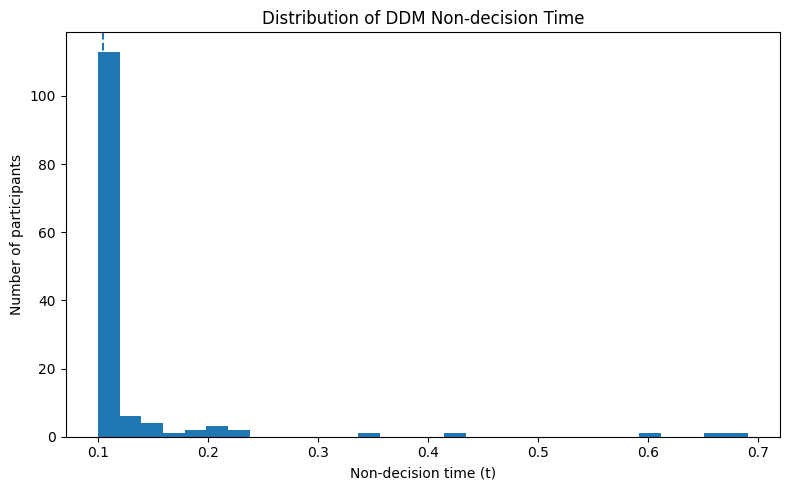

In [12]:
# ============================================================
# INVESTIGATE NON-DECISION TIME (t)
# ============================================================

print("=" * 60)
print("NON-DECISION TIME DISTRIBUTION")
print("=" * 60)

print(qc["t"].describe())

print("\nNumber of participants at/near lower bound:")
print("t <= 0.101:", (qc["t"] <= 0.101).sum())
print("t <= 0.102:", (qc["t"] <= 0.102).sum())
print("t <= 0.103:", (qc["t"] <= 0.103).sum())
print("t <= 0.105:", (qc["t"] <= 0.105).sum())
print("t <= 0.110:", (qc["t"] <= 0.110).sum())

print("\nNumber of participants at/near upper bound:")
print("t >= 0.690:", (qc["t"] >= 0.690).sum())
print("t >= 0.695:", (qc["t"] >= 0.695).sum())

# ------------------------------------------------------------
# Exact participants with t close to lower bound
# ------------------------------------------------------------

near_t_lower = qc[qc["t"] <= 0.105].copy()

print("\n" + "=" * 60)
print("PARTICIPANTS WITH t <= 0.105")
print("=" * 60)

print(
    near_t_lower[
        ["subject", "group", "n_trials", "accuracy", "v", "a", "t"]
    ].sort_values("t").to_string(index=False)
)

# ------------------------------------------------------------
# Group-wise t
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("t BY GROUP")
print("=" * 60)

print(
    qc.groupby("group")["t"]
      .agg(["count", "mean", "std", "min", "median", "max"])
)

# ------------------------------------------------------------
# How many near-boundary t values in each group?
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("t <= 0.105 BY GROUP")
print("=" * 60)

group_t_qc = (
    qc.groupby("group")
      .agg(
          n=("t", "size"),
          near_lower=("t", lambda x: (x <= 0.105).sum())
      )
)

group_t_qc["percentage"] = (
    group_t_qc["near_lower"] /
    group_t_qc["n"] * 100
)

print(group_t_qc)

# ------------------------------------------------------------
# Distribution plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))
plt.hist(qc["t"], bins=30)
plt.axvline(0.105, linestyle="--")
plt.xlabel("Non-decision time (t)")
plt.ylabel("Number of participants")
plt.title("Distribution of DDM Non-decision Time")
plt.tight_layout()
plt.show()

In [13]:
print("ddm_records type:", type(ddm_records))
print("Number of records:", len(ddm_records))

if len(ddm_records) > 0:
    print("\nFirst record:")
    print(type(ddm_records[0]))
    print(ddm_records[0])

ddm_records type: <class 'list'>
Number of records: 136

First record:
<class 'dict'>
{'v': 0.051163081809562354, 'a': 1.212616051483962, 't': 0.10679702015082693, 'subject': 'manit', 'group': 'ADHD', 'n_trials': 77, 'accuracy': np.float64(0.5194805194805194)}


In [14]:
import inspect

print(inspect.signature(fit_ddm_subject))

(rt_arr, correct_arr, subject_id=None)


In [15]:
import inspect

source = inspect.getsource(fit_ddm_subject)

with open("fit_ddm_subject_source.txt", "w") as f:
    f.write(source)

print(source)

def fit_ddm_subject(rt_arr, correct_arr, subject_id=None):

    try:

        # Create PyDDM sample
        sample = Sample.from_numpy_array(
            np.column_stack([
                rt_arr,
                correct_arr.astype(int)
            ])
        )

        # ----------------------------------------------------
        # 3-PARAMETER DDM
        # ----------------------------------------------------

        model = Model(

            name=f"subj_{subject_id}",

            # Drift rate
            # Allow both positive and negative drift
            drift=DriftConstant(
                drift=Fittable(
                    minval=-5.0,
                    maxval=5.0
                )
            ),

            # Diffusion noise fixed at 1
            noise=NoiseConstant(
                noise=1.0
            ),

            # Boundary separation
            bound=BoundConstant(
                B=Fittable(
                    minval=0.3,
                    maxval=2.5
      

ddm_clean columns:
['subj_idx', 'group', 'emotion', 'rt', 'response']

ddm_params_raw columns:
['subject', 'group', 'n_trials', 'accuracy', 'v', 'a', 't']



VALIDATION COMPLETE
Participants successfully validated: 136

First rows:
     subject   group  n_trials  observed_accuracy  predicted_accuracy  \
0      manit    ADHD        77           0.519481            0.530256   
1    harshit  NORMAL        91           0.417582            0.437300   
2     aditya    ADHD        41           0.341463            0.396177   
3   amrit(C)    ADHD        44           0.500000            0.493425   
4  amrit raj  NORMAL        44           0.681818            0.656823   

   observed_mean_rt  predicted_mean_rt         v         a         t  
0          2.382399           1.640181  0.051163  1.212616  0.106797  
1          1.969223           1.542434 -0.109631  1.172760  0.105275  
2          2.947500           1.945279 -0.159129  1.347080  0.104298  
3          2.670971           2.409804 -0.005715  1.516453  0.107042  
4          1.580044           1.235140  0.317485  1.044804  0.103632  

ACCURACY VALIDATION
       observed_accuracy  predicted_acc

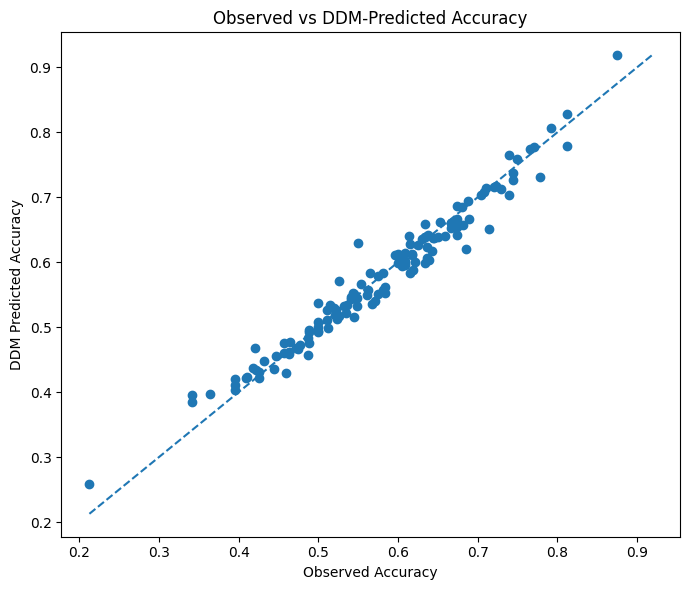

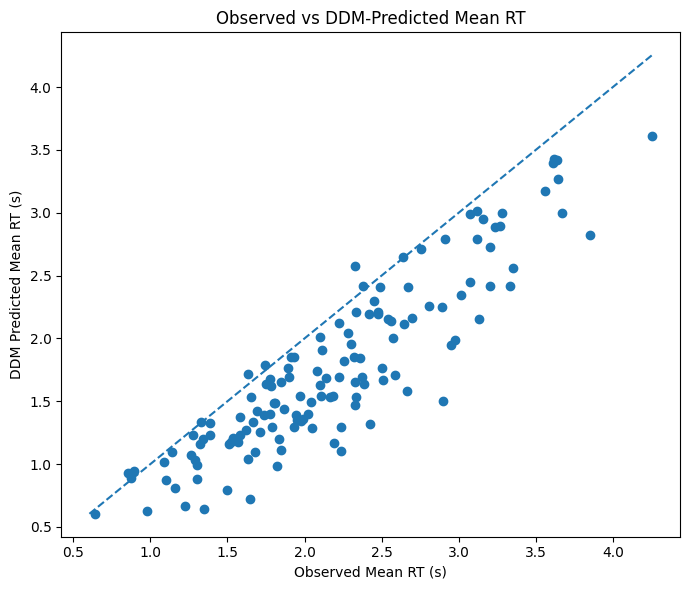


10 LARGEST ACCURACY ERRORS
       subject  group  n_trials  observed_accuracy  predicted_accuracy  accuracy_error         v        a        t
        saiyam   ADHD        40           0.550000            0.630036        0.080036  0.408565 0.665471 0.121205
        rugved AUTISM        35           0.685714            0.619860       -0.065855  0.234969 1.062642 0.104341
          amay NORMAL        42           0.714286            0.651866       -0.062419  0.313092 1.023581 0.106217
        aditya   ADHD        41           0.341463            0.396177        0.054713 -0.159129 1.347080 0.104298
       yuvaan  AUTISM        38           0.421053            0.468564        0.047512 -0.055619 1.153692 0.108599
parth continua NORMAL        45           0.777778            0.731844       -0.045934  0.439546 1.169841 0.106411
        avaesh NORMAL        47           0.212766            0.258169        0.045403 -0.488784 1.106238 0.108631
           ali AUTISM        38           0.526316  

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pyddm import (
    Model,
    DriftConstant,
    NoiseConstant,
    BoundConstant,
    OverlayChain,
    OverlayNonDecision,
    OverlayUniformMixture
)

# ============================================================
# DDM MODEL FIT VALIDATION
# ============================================================

# ------------------------------------------------------------
# 1. Check columns
# ------------------------------------------------------------

print("ddm_clean columns:")
print(ddm_clean.columns.tolist())

print("\nddm_params_raw columns:")
print(ddm_params_raw.columns.tolist())


# ------------------------------------------------------------
# 2. Recreate the EXACT fitted model
# ------------------------------------------------------------

def create_fitted_model(v, a, t):

    model = Model(

        name="fitted_subject",

        drift=DriftConstant(
            drift=v
        ),

        noise=NoiseConstant(
            noise=1.0
        ),

        bound=BoundConstant(
            B=a
        ),

        overlay=OverlayChain(
            overlays=[

                OverlayNonDecision(
                    nondectime=t
                ),

                OverlayUniformMixture(
                    umixturecoef=0.02
                )
            ]
        ),

        dx=0.01,
        dt=0.01,
        T_dur=10.5
    )

    return model


# ------------------------------------------------------------
# 3. Validate every participant
# ------------------------------------------------------------

validation_results = []

for _, row in ddm_params_raw.iterrows():

    subject = row["subject"]

    # IMPORTANT:
    # ddm_params_raw uses "subject"
    # ddm_clean uses "subj_idx"
    subdata = ddm_clean[
        ddm_clean["subj_idx"] == subject
    ].copy()

    if len(subdata) == 0:
        print(f"No data found for subject: {subject}")
        continue

    # --------------------------------------------------------
    # Observed statistics
    # --------------------------------------------------------

    observed_accuracy = subdata["response"].mean()
    observed_mean_rt = subdata["rt"].mean()

    # --------------------------------------------------------
    # Reconstruct model using ALREADY FITTED parameters
    # --------------------------------------------------------

    model = create_fitted_model(
        v=row["v"],
        a=row["a"],
        t=row["t"]
    )

    try:

        solution = model.solve()

        # Predicted probability of correct response
        predicted_accuracy = solution.prob_correct()

        # Predicted mean RT
        predicted_mean_rt = solution.mean_rt()

        validation_results.append({

            "subject": subject,
            "group": row["group"],
            "n_trials": len(subdata),

            "observed_accuracy": observed_accuracy,
            "predicted_accuracy": predicted_accuracy,

            "observed_mean_rt": observed_mean_rt,
            "predicted_mean_rt": predicted_mean_rt,

            "v": row["v"],
            "a": row["a"],
            "t": row["t"]

        })

    except Exception as e:

        print(
            f"Prediction failed for {subject}: {e}"
        )


# ------------------------------------------------------------
# 4. Create validation DataFrame
# ------------------------------------------------------------

validation_df = pd.DataFrame(validation_results)

print("\n" + "=" * 60)
print("VALIDATION COMPLETE")
print("=" * 60)

print(
    "Participants successfully validated:",
    len(validation_df)
)

print("\nFirst rows:")
print(validation_df.head())


# ============================================================
# 5. Prediction errors
# ============================================================

validation_df["accuracy_error"] = (
    validation_df["predicted_accuracy"]
    - validation_df["observed_accuracy"]
)

validation_df["rt_error"] = (
    validation_df["predicted_mean_rt"]
    - validation_df["observed_mean_rt"]
)

validation_df["absolute_accuracy_error"] = (
    validation_df["accuracy_error"].abs()
)

validation_df["absolute_rt_error"] = (
    validation_df["rt_error"].abs()
)


# ============================================================
# 6. Overall accuracy validation
# ============================================================

print("\n" + "=" * 60)
print("ACCURACY VALIDATION")
print("=" * 60)

print(
    validation_df[
        [
            "observed_accuracy",
            "predicted_accuracy",
            "accuracy_error",
            "absolute_accuracy_error"
        ]
    ].describe()
)


# ============================================================
# 7. Overall RT validation
# ============================================================

print("\n" + "=" * 60)
print("RT VALIDATION")
print("=" * 60)

print(
    validation_df[
        [
            "observed_mean_rt",
            "predicted_mean_rt",
            "rt_error",
            "absolute_rt_error"
        ]
    ].describe()
)


# ============================================================
# 8. Observed vs predicted correlations
# ============================================================

accuracy_corr = validation_df[
    ["observed_accuracy", "predicted_accuracy"]
].corr().iloc[0, 1]

rt_corr = validation_df[
    ["observed_mean_rt", "predicted_mean_rt"]
].corr().iloc[0, 1]

print("\n" + "=" * 60)
print("OBSERVED vs PREDICTED CORRELATIONS")
print("=" * 60)

print(
    "Accuracy correlation:",
    round(accuracy_corr, 3)
)

print(
    "Mean RT correlation:",
    round(rt_corr, 3)
)


# ============================================================
# 9. Mean observed vs predicted
# ============================================================

print("\n" + "=" * 60)
print("OVERALL OBSERVED vs PREDICTED")
print("=" * 60)

print(
    "Observed mean accuracy:",
    round(
        validation_df["observed_accuracy"].mean(),
        4
    )
)

print(
    "Predicted mean accuracy:",
    round(
        validation_df["predicted_accuracy"].mean(),
        4
    )
)

print(
    "Observed mean RT:",
    round(
        validation_df["observed_mean_rt"].mean(),
        4
    ),
    "seconds"
)

print(
    "Predicted mean RT:",
    round(
        validation_df["predicted_mean_rt"].mean(),
        4
    ),
    "seconds"
)


# ============================================================
# 10. Mean absolute errors
# ============================================================

print("\n" + "=" * 60)
print("MEAN ABSOLUTE PREDICTION ERROR")
print("=" * 60)

print(
    "Accuracy MAE:",
    round(
        validation_df["absolute_accuracy_error"].mean(),
        4
    )
)

print(
    "RT MAE:",
    round(
        validation_df["absolute_rt_error"].mean(),
        4
    ),
    "seconds"
)


# ============================================================
# 11. Accuracy: observed vs predicted
# ============================================================

plt.figure(figsize=(7, 6))

plt.scatter(
    validation_df["observed_accuracy"],
    validation_df["predicted_accuracy"]
)

lims = [
    min(
        validation_df["observed_accuracy"].min(),
        validation_df["predicted_accuracy"].min()
    ),
    max(
        validation_df["observed_accuracy"].max(),
        validation_df["predicted_accuracy"].max()
    )
]

plt.plot(
    lims,
    lims,
    linestyle="--"
)

plt.xlabel("Observed Accuracy")
plt.ylabel("DDM Predicted Accuracy")
plt.title("Observed vs DDM-Predicted Accuracy")

plt.tight_layout()
plt.show()


# ============================================================
# 12. RT: observed vs predicted
# ============================================================

plt.figure(figsize=(7, 6))

plt.scatter(
    validation_df["observed_mean_rt"],
    validation_df["predicted_mean_rt"]
)

lims = [
    min(
        validation_df["observed_mean_rt"].min(),
        validation_df["predicted_mean_rt"].min()
    ),
    max(
        validation_df["observed_mean_rt"].max(),
        validation_df["predicted_mean_rt"].max()
    )
]

plt.plot(
    lims,
    lims,
    linestyle="--"
)

plt.xlabel("Observed Mean RT (s)")
plt.ylabel("DDM Predicted Mean RT (s)")
plt.title("Observed vs DDM-Predicted Mean RT")

plt.tight_layout()
plt.show()


# ============================================================
# 13. Identify largest prediction errors
# ============================================================

print("\n" + "=" * 60)
print("10 LARGEST ACCURACY ERRORS")
print("=" * 60)

print(
    validation_df.nlargest(
        10,
        "absolute_accuracy_error"
    )[
        [
            "subject",
            "group",
            "n_trials",
            "observed_accuracy",
            "predicted_accuracy",
            "accuracy_error",
            "v",
            "a",
            "t"
        ]
    ].to_string(index=False)
)


print("\n" + "=" * 60)
print("10 LARGEST RT ERRORS")
print("=" * 60)

print(
    validation_df.nlargest(
        10,
        "absolute_rt_error"
    )[
        [
            "subject",
            "group",
            "n_trials",
            "observed_mean_rt",
            "predicted_mean_rt",
            "rt_error",
            "v",
            "a",
            "t"
        ]
    ].to_string(index=False)
)


# ============================================================
# 14. Save
# ============================================================

validation_df.to_csv(
    "ddm_model_validation.csv",
    index=False
)

print("\nSaved: ddm_model_validation.csv")

yuvaan: not found


C:\Users\abhia\AppData\Local\Temp\ipykernel_27976\4015856897.py:83: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(pdf_total, time_axis)


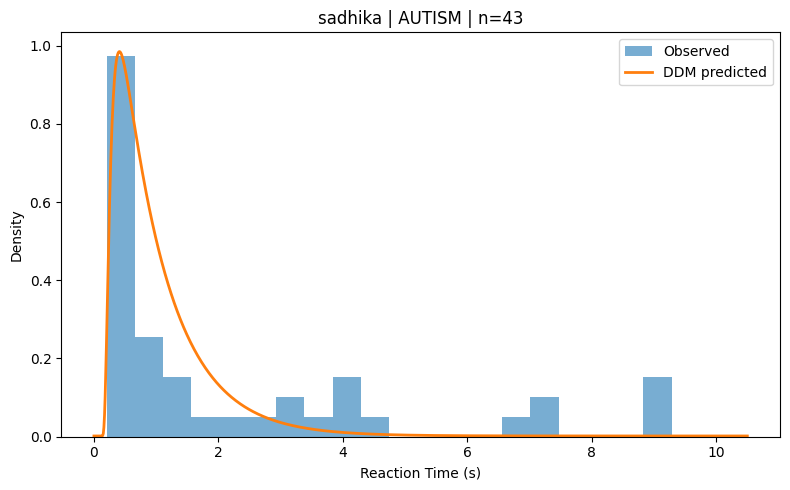

C:\Users\abhia\AppData\Local\Temp\ipykernel_27976\4015856897.py:127: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz(
C:\Users\abhia\AppData\Local\Temp\ipykernel_27976\4015856897.py:132: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  np.trapz(



sadhika | AUTISM
Number of trials: 43
Observed mean RT: 2.239 s
Predicted mean RT: 1.107 s
Observed median RT: 0.835 s
Predicted median RT: 0.807 s
Observed 90th percentile: 7.103 s
Predicted 90th percentile: 2.11 s


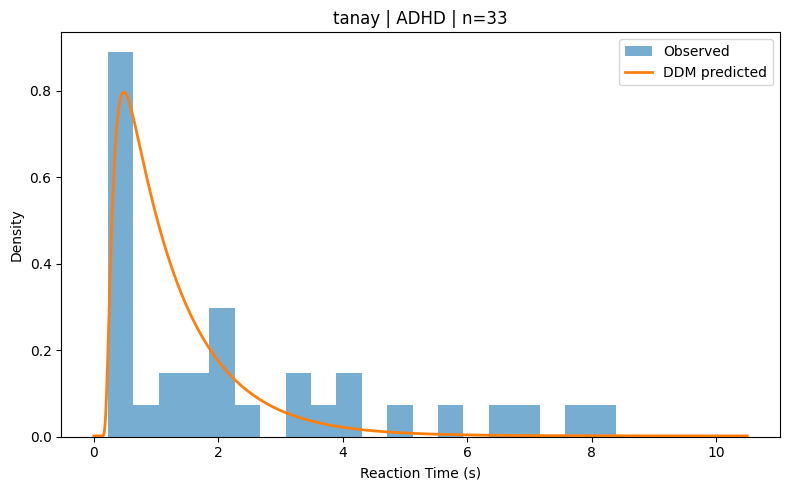


tanay | ADHD
Number of trials: 33
Observed mean RT: 2.423 s
Predicted mean RT: 1.321 s
Observed median RT: 1.818 s
Predicted median RT: 0.975 s
Observed 90th percentile: 6.42 s
Predicted 90th percentile: 2.58 s
goranshi: not found


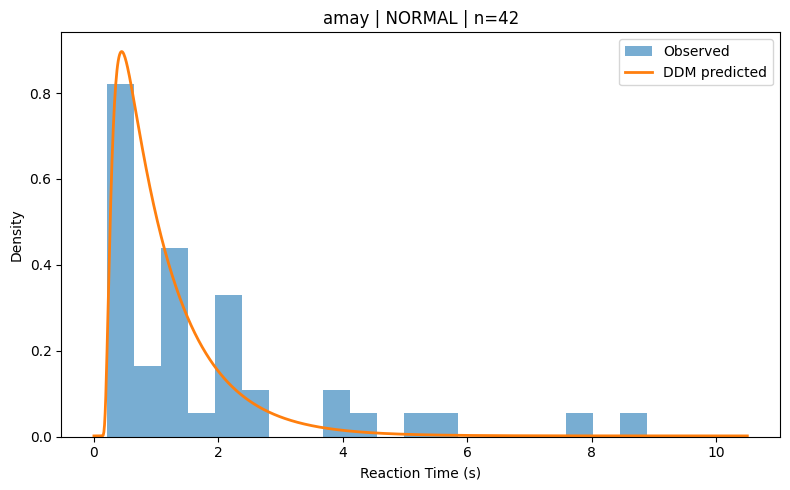


amay | NORMAL
Number of trials: 42
Observed mean RT: 1.836 s
Predicted mean RT: 1.196 s
Observed median RT: 1.162 s
Predicted median RT: 0.879 s
Observed 90th percentile: 4.302 s
Predicted 90th percentile: 2.299 s


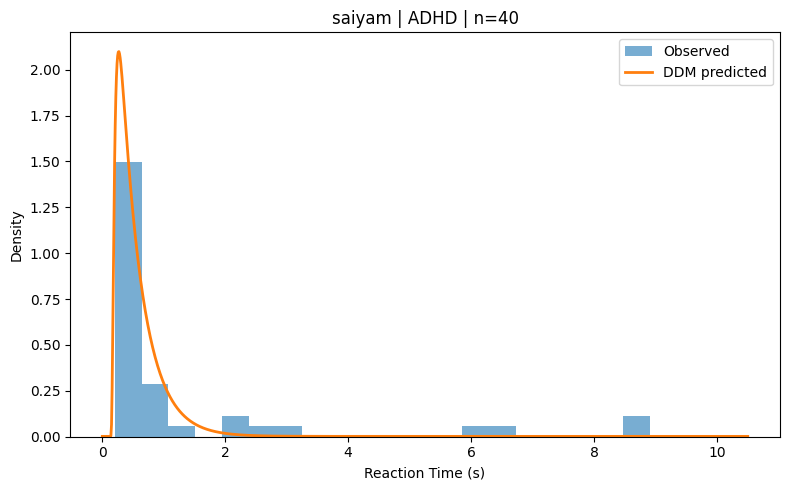


saiyam | ADHD
Number of trials: 40
Observed mean RT: 1.349 s
Predicted mean RT: 0.646 s
Observed median RT: 0.406 s
Predicted median RT: 0.45 s
Observed 90th percentile: 3.431 s
Predicted 90th percentile: 1.066 s


In [17]:
# ============================================================
# OBSERVED VS DDM-PREDICTED RT DISTRIBUTIONS
# Using the PyDDM Solution directly
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

selected_subjects = [
    "yuvaan",
    "sadhika",
    "tanay",
    "goranshi",
    "amay",
    "saiyam"
]

for subject in selected_subjects:

    # --------------------------------------------------------
    # Get fitted parameters
    # --------------------------------------------------------

    row = ddm_params_raw[
        ddm_params_raw["subject"] == subject
    ]

    if len(row) == 0:
        print(f"{subject}: not found")
        continue

    row = row.iloc[0]

    # --------------------------------------------------------
    # Get participant's observed data
    # --------------------------------------------------------

    subdata = ddm_clean[
        ddm_clean["subj_idx"] == subject
    ].copy()

    if len(subdata) == 0:
        print(f"{subject}: no trials found")
        continue

    observed_rt = subdata["rt"].values

    # --------------------------------------------------------
    # Recreate fitted model
    # --------------------------------------------------------

    model = create_fitted_model(
        v=row["v"],
        a=row["a"],
        t=row["t"]
    )

    # --------------------------------------------------------
    # Solve model
    # --------------------------------------------------------

    solution = model.solve()

    # --------------------------------------------------------
    # Get PyDDM predicted RT distribution
    # --------------------------------------------------------

    time_axis = solution.t_domain

    # Correct responses
    pdf_correct = solution.pdf_corr()

    # Incorrect responses
    pdf_error = solution.pdf_err()

    # Total RT density
    pdf_total = pdf_correct + pdf_error

    # --------------------------------------------------------
    # Normalize predicted distribution
    # --------------------------------------------------------

    area = np.trapz(pdf_total, time_axis)

    if area > 0:
        pdf_total = pdf_total / area

    # --------------------------------------------------------
    # Observed histogram
    # --------------------------------------------------------

    plt.figure(figsize=(8, 5))

    plt.hist(
        observed_rt,
        bins=20,
        density=True,
        alpha=0.6,
        label="Observed"
    )

    # DDM predicted density
    plt.plot(
        time_axis,
        pdf_total,
        linewidth=2,
        label="DDM predicted"
    )

    plt.xlabel("Reaction Time (s)")
    plt.ylabel("Density")

    plt.title(
        f"{subject} | {row['group']} | n={len(observed_rt)}"
    )

    plt.legend()

    plt.tight_layout()
    plt.show()

    # --------------------------------------------------------
    # Calculate predicted mean RT from distribution
    # --------------------------------------------------------

    predicted_mean_rt = (
        np.trapz(
            time_axis * pdf_total,
            time_axis
        )
        /
        np.trapz(
            pdf_total,
            time_axis
        )
    )

    predicted_median_rt = np.interp(
        0.5,
        np.cumsum(pdf_total) /
        np.sum(pdf_total),
        time_axis
    )

    predicted_90_rt = np.interp(
        0.9,
        np.cumsum(pdf_total) /
        np.sum(pdf_total),
        time_axis
    )

    # --------------------------------------------------------
    # Print comparison
    # --------------------------------------------------------

    print("\n" + "=" * 60)
    print(subject, "|", row["group"])

    print("Number of trials:", len(observed_rt))

    print(
        "Observed mean RT:",
        round(np.mean(observed_rt), 3),
        "s"
    )

    print(
        "Predicted mean RT:",
        round(predicted_mean_rt, 3),
        "s"
    )

    print(
        "Observed median RT:",
        round(np.median(observed_rt), 3),
        "s"
    )

    print(
        "Predicted median RT:",
        round(predicted_median_rt, 3),
        "s"
    )

    print(
        "Observed 90th percentile:",
        round(np.percentile(observed_rt, 90), 3),
        "s"
    )

    print(
        "Predicted 90th percentile:",
        round(predicted_90_rt, 3),
        "s"
    )

In [18]:
print(group_t_qc)

         n  near_lower  percentage
group                             
ADHD    67          19   28.358209
ADHD-H   1           0    0.000000
AUTISM  20          10   50.000000
NORMAL  48          18   37.500000


In [20]:
near_t_lower = qc[qc["t"] <= 0.105].copy()

print(
    near_t_lower[
        ["subject", "group", "n_trials", "accuracy", "v", "a", "t"]
    ].sort_values("t").to_string(index=False)
)

         subject  group  n_trials  accuracy         v        a        t
          armaan AUTISM        31  0.548387  0.047471 1.519594 0.100122
        GURSHEEN   ADHD        40  0.650000  0.233553 1.251715 0.100256
          avyaan   ADHD        43  0.674419  0.394662 1.019282 0.100435
        shivansh AUTISM        36  0.472222 -0.031902 1.663404 0.100514
          harman   ADHD        41  0.634146  0.427495 0.791041 0.100696
        shivaank AUTISM        43  0.534884  0.035971 1.296650 0.101032
      karan kota   ADHD        45  0.600000  0.220894 1.054453 0.101066
          naitik   ADHD        44  0.409091 -0.120350 1.327513 0.101069
         nishant NORMAL        48  0.687500  0.414820 1.014551 0.101249
           Johan   ADHD        31  0.548387  0.072556 1.255054 0.101370
       abhimanyu NORMAL        48  0.604167  0.146313 1.417137 0.101376
           kosar   ADHD        33  0.515152  0.071003 0.964868 0.101564
           sagar   ADHD        41  0.512195  0.012692 1.811791 0